In [ ]:
import copy 
import json

import glob

ATTACK = '1'
BENIGN = '0'

DISCOVERY = "NF Discovery"
ADDNF     = "NF Registration"
REMOVENF  = "NF Deregistration"

SESSION_DELETION = "Session Deletion"
SESSION_ESTABLISHMENT = "Session Establishment"
SESSION_MODIFICATION = "Session Modification (DoS Session)"
SEID_FUZZING = "Session Modification (SEID Fuzzing)"

GTP = "GTP message (Uplink Spoofing)"
PFCP_IN_GTP = "PFCP in GTP"

my_json = []
for filepath in sorted(glob.glob("./output/dissection/*.json")):
    with open(filepath, 'r') as f:
        data = json.load(f)
        my_json += data

dict_by_type = {
    DISCOVERY : [],
    ADDNF     : [],
    REMOVENF  : [],
    SESSION_DELETION      : [],
    SESSION_MODIFICATION  : [],
    SESSION_ESTABLISHMENT : [],
    GTP         : [],
    PFCP_IN_GTP : [],
    SEID_FUZZING: []
}

dict = {
    ATTACK: copy.deepcopy(dict_by_type),
    BENIGN: copy.deepcopy(dict_by_type)
}

for dissected_pkt in my_json:

    is_attack = dissected_pkt["common"]["is_attack"]

    if int(is_attack) >= 0 :
        if "http2" in dissected_pkt["protocols"]:

            for layer in dissected_pkt["protocols"]["http2"]:

                if "path" in layer:

                    # Discovery Requests
                    if "/nnrf-disc" in layer["path"]:
                        dict[is_attack][DISCOVERY].append(dissected_pkt)

                    # Add and remove NF Requests
                    if "/nnrf-nfm" in layer["path"]:

                        if layer["method"] == "PUT":
                            dict[is_attack][ADDNF].append(dissected_pkt)
                        elif layer["method"] == "DELETE":
                            dict[is_attack][REMOVENF].append(dissected_pkt)

                    # Any fuzzing request
                    if "/nudm" in layer["path"] or "/namf" in layer["path"]:

                        path_to_correct = [
                            ("/namf-callback/v1/smContextStatus/imsi/"),
                            ("/nudm-sdm/v2/imsi/sdm-subscriptions/"),
                            ("/namf-mt/v1/ue-contexts","ue-reachind"),
                            ("/nudm-rsds/v1","sm-delivery-status"),
                            ("/nudm-ssau/v1", "AF_GUIDANCE_FOR_URSP/authorize"),
                            ("/namf-comm/v1/ue-contexts","n1-n2-messages/subscriptions"),
                            ("/nudm-sdm/v2","lcs-privacy-data"),
                            ("/namf-comm/v1/ue-contexts","n1-n2-messages"),
                            ("/nudm-ssau/v1","AF_GUIDANCE_FOR_URSP"),
                            ("/namf-mbs-bc/v1/mbs-contexts"),
                            ("/namf-comm/v1/ue-contexts/")
                        ]

                        for path_parts in path_to_correct:
                            all_parts = True
                            for path_part in path_parts:
                                if path_part not in layer["path"]:
                                    all_parts = False
                            if all_parts:
                                if len(path_parts) == 2:
                                    layer["path"] = "/".join(path_parts)
                                else :
                                    layer["path"] = path_parts

                        if layer["path"] not in dict[is_attack]:
                            dict[is_attack][layer["path"]] = []

                        dict[is_attack][layer["path"]].append(dissected_pkt)

        if "pfcp" in dissected_pkt["protocols"]:

            for layer in dissected_pkt["protocols"]["pfcp"]:

                if "msg_type" in layer:

                    # PFCP Deletion Requests
                    if int(layer["msg_type"]) == 54:
                        dict[is_attack][SESSION_DELETION].append(dissected_pkt)

                    # PFCP Modification Requests
                    if int(layer["msg_type"]) == 52:

                        if int(is_attack):

                            if dissected_pkt["common"]["type"] == "seid_fuzzing":
                                dict[is_attack][SEID_FUZZING].append(dissected_pkt)
                            else :
                                dict[is_attack][SESSION_MODIFICATION].append(dissected_pkt)
                        else:
                            dict[is_attack][SEID_FUZZING].append(dissected_pkt)
                            dict[is_attack][SESSION_MODIFICATION].append(dissected_pkt)

                    # PFCP Establishment Requests
                    if int(layer["msg_type"]) == 50:
                        dict[is_attack][SESSION_ESTABLISHMENT].append(dissected_pkt)

        if "gtp" in dissected_pkt["protocols"]:

                for layer in dissected_pkt["protocols"]["gtp"]:

                    if layer["flags"]=="0x34":

                        # PFCP IN GTP
                        # We take only the request not the responses
                        # (Because the response are not sent to the EVIL)
                        if "pfcp" in dissected_pkt["protocols"] and int(dissected_pkt["protocols"]["pfcp"][0]["msg_type"]) == 54:
                            dict[is_attack][PFCP_IN_GTP].append(dissected_pkt)

                        else:
                            dict[is_attack][GTP].append(dissected_pkt)

print("BENIGN MESSAGES PER ATTACK TYPE\n\n")
print("ATTACKS")
for key,value in dict[ATTACK].items():
    print(key, len(value))

print("-------")

print("BENIGN")
for key,value in dict[BENIGN].items():
    print(key, len(value))

BENIGN MESSAGES PER ATTACK TYPE


ATTACKS
NF Discovery 1293
NF Registration 633
NF Deregistration 754
Session Deletion 9125
Session Modification (DoS Session) 196
Session Establishment 10500
GTP message (Uplink Spoofing) 107
PFCP in GTP 125
Session Modification (SEID Fuzzing) 11249
/nudm-sdm/v2/imsi/sm-data 124
/nudm-sdm/v2/imsi/sdm-subscriptions/ 180
/nudm-ueau/v1/suci/security-information/generate-auth-data 38
/nudm-ueau/v1/imsi/auth-events 40
/nudm-sdm/v2/imsi/nssai 38
/nudm-uecm/v1/imsi/registrations/amf-3gpp-access 42
/nudm-sdm/v2/imsi/am-data 38
/nudm-sdm/v2/imsi/smf-select-data 38
/nudm-sdm/v2/imsi/ue-context-in-smf-data 40
/namf-mbs-comm/v1/n2-messages/transfer 90
/namf-comm/v1/ue-contexts/ 539
/namf-comm/v1/non-ue-n2-messages/transfer 180
/nudm-ueau/v1/imsi-975595332110/auth-events/RbOaDISbXG 30
/nudm-ueau/v1/imsi-91012153/security-information-rg 30
/nudm-ueau/v1/gci-y06rBpco8/security-information/generate-auth-data 30
/namf-loc/v1/qYp/cancel-pos-info 30
/namf-loc/v1/imsi-6747

In [19]:
dict_to_jacard = copy.deepcopy(dict)

for is_attack, natures in dict.items():
    for nature,packets in natures.items():
        dict_to_jacard[is_attack][nature] = []
        for packet in packets:
            for protocol,layers in packet["protocols"].items():
                for layer in layers:
                    dict_to_jacard[is_attack][nature].append(list(layer.keys()))

In [20]:
import pandas as pd 
from sklearn.metrics import pairwise_distances
import numpy as np

result = {
    "api_fuzzing" : np.array([])
}

for nature,attack_packets in dict_to_jacard[ATTACK].items():

    # print(f"Processing {nature}")

    if nature in dict_to_jacard[BENIGN]:

        packets = dict_to_jacard[BENIGN][nature]
        all_benign_keys = set([k for pkt in packets for k in pkt])
        for attack_packet in attack_packets:
            all_benign_keys.update(set(attack_packet))

        Y = pd.DataFrame([{k: bool(k in pkt) for k in all_benign_keys} for pkt in packets])
        X = pd.DataFrame([{k: bool(k in attack_packet) for k in all_benign_keys} for attack_packet in attack_packets])

        if len(Y) > 0 and len(X) > 0:
            distances = pairwise_distances(X.values, Y.values, metric="jaccard")
            distances = distances.flatten()
            result[nature] = distances

        else :
            result[nature] = np.array([1.]*len(attack_packets))
    else :
        result[nature] = np.array([1.]*len(attack_packets))


In [21]:
result2 = result.copy()
result2["api_fuzzing"] = np.array([])

for nature, distances in result.items():
    if "/" in nature:
        result2["api_fuzzing"] = np.concatenate((result2["api_fuzzing"], distances))
        del result2[nature]

In [22]:
percent_min_zero = {}

for nature, distances in result2.items():
    if nature != "api_fuzzing" and len(distances):
        percent_min_zero[nature] = int(len(np.where(distances==0)[0]) * 100 / len(distances))

In [23]:
percent_min_zero

{'NF Discovery': 26,
 'NF Registration': 85,
 'NF Deregistration': 80,
 'Session Deletion': 97,
 'Session Modification (DoS Session)': 0,
 'Session Establishment': 100,
 'GTP message (Uplink Spoofing)': 48,
 'PFCP in GTP': 0,
 'Session Modification (SEID Fuzzing)': 57}

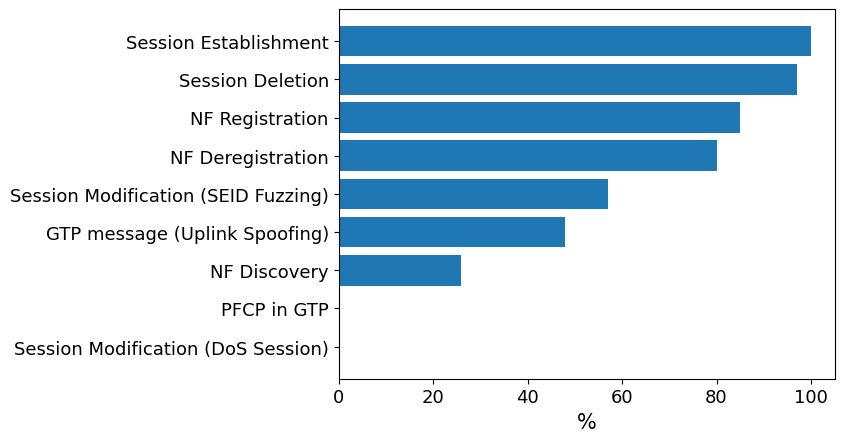

In [24]:
import matplotlib.pyplot as plt

sorted_items = sorted(percent_min_zero.items(), key=lambda x: x[1], reverse=False)
labels, values = zip(*sorted_items)

plt.rcParams.update({
    'font.size': 14,          # Taille de base du texte
    'axes.titlesize': 16,     # Taille du titre de l’axe
    'axes.labelsize': 15,     # Taille des labels x/y
    'xtick.labelsize': 13,    # Taille des ticks de l’axe X
    'ytick.labelsize': 13,    # Taille des ticks de l’axe Y
    'legend.fontsize': 12,    # Taille de la légende
})

plt.barh(labels,values)
# plt.title('Ratio of attack messages semantically identical to at least one benign message')
plt.xlabel('%')
plt.show()

In [9]:
nb_no_zero = 0
nb_fuzz_func = 0

for nature,distances in result.items():
    if "/" in nature : 
        nb_fuzz_func += 1
        nb_zero = int(len(np.where(distances==0)[0]))
        if nb_zero > 0:
            nb_no_zero += 1

In [10]:
print(f"Percent of fuzzing requests never seen in normal {(1-nb_no_zero/nb_fuzz_func)*100}")


Percent of fuzzing requests never seen in normal 88.88888888888889


In [139]:
stats = {}

for nature, distances in result.items():
    
    stats[nature] = {
        "min": np.min(distances),
        "max": np.max(distances),
        "mean": np.mean(distances),
        "median": np.median(distances),
        "std": np.std(distances),
        "q1": np.percentile(distances, 25),
        "q3": np.percentile(distances, 75),
        "iqr": np.percentile(distances, 75) - np.percentile(distances, 25)
    }

In [140]:
# --- Conversion en DataFrame pour simplifier le plot ---
df = pd.DataFrame({k: pd.Series(v) for k, v in stats.items()})
df

,api_fuzzing,discovery,addNf,removeNf,sessionDeletion,sessionModification,sessionEstablishment,gtp,pfcp_in_gtp,seid_fuzzing
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.350877,0.0,0.000000,1.0,0.000000
max,1.000000,0.588235,0.500000,0.111111,0.939394,0.841463,0.0,0.955556,1.0,0.781818
mean,0.196036,0.164264,0.256410,0.023310,0.006180,0.635055,0.0,0.007837,1.0,0.253776
median,0.125000,0.090909,0.500000,0.000000,0.000000,0.628571,0.0,0.000000,1.0,0.000000
std,0.198463,0.162029,0.249918,0.045240,0.075944,0.120863,0.0,0.086184,0.0,0.312316
q1,0.125000,0.000000,0.000000,0.000000,0.000000,0.525641,0.0,0.000000,1.0,0.000000
q3,0.222222,0.300000,0.500000,0.000000,0.000000,0.705128,0.0,0.000000,1.0,0.477477
iqr,0.097222,0.300000,0.500000,0.000000,0.000000,0.179487,0.0,0.000000,0.0,0.477477


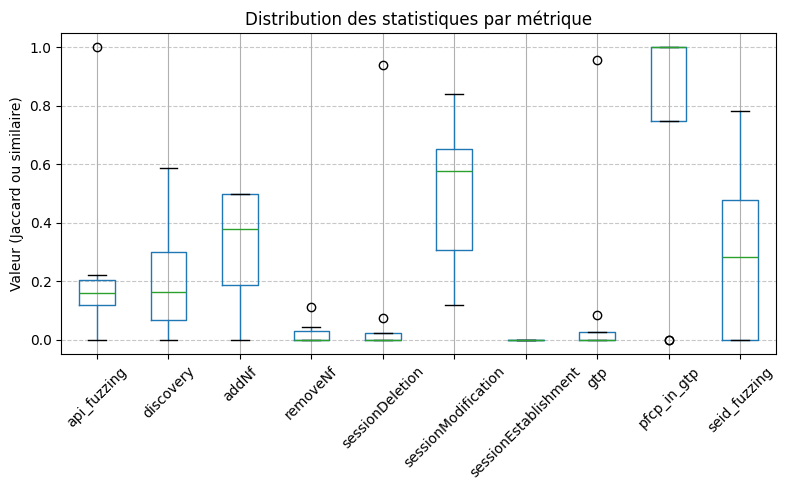

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df.boxplot()
plt.title("Distribution des statistiques par métrique")
plt.ylabel("Valeur (Jaccard ou similaire)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()